#### Контрольные вопросы (1 балл)

1. что такое порядок точности метода?
Ответ: характеристика того, насколько быстро уменьшается погрешность метода при уменьшении шага вычислений

2. какой порядок метода будет при численном дифференцировании по $N$ узлам и почему?
Ответ: N-1
Ошибка интерполяции:
$$f(x)=P_{N-1} (x)+\frac{f^{(N)}(\epsilon)}{N!} \omega_N (x)$$
где
$$\omega_N (x)=(x-x_1)(x-x_2)...(x-x_N)$$
Если продифференцировать это выражение, получаем ошибку для производной:
$$f'(x_0)-P_{N-1}' (x_0)=\frac{f^{(N)}(\epsilon)}{N!} \omega_N (x)'$$
Так как $\omega_N (x)$ содержит N множителей, при равномерном шаге h она ведет себя как $O(h^N)$, а её производная $O(h^{N-1})$

3. как называется матрица СЛАУ на коэффициенты метода неопределенных коэффицентов? Существует ли единственное решение системы и почему?
Ответ: она называется матрица Вандермонда
Да, существует, если все узлы $x_i$ различны.
Потому что определитель матрицы Вандермонда равен проихведению все возможны разночтей $x_i$


In [ ]:
#скрипт, который реализует алгоритм метода неопределенных коэффициентов
import numpy as np
import numpy.linalg as la

def get_diff(u, l, m, h):
    n = u.size
    v = np.linspace(-l,m, n)
    # формируем матрицу системы в нужном виде
    A = np.fliplr(np.vander(v, v.size)).T 
    b = np.zeros(n)
    b[1] = 1
    alpha = la.solve(A,b)
    diff = 1/h*alpha.dot(u.T)
    return diff

p = 4 # порядок метода
a = np.pi/3
b = np.pi/2
h = (b-a)/p
print('h = ', h)
x = np.linspace(a, b, p+1)
u = np.sin(x) #ищем производную синуса

diff = get_diff(u, 0, p, h)
print('diff = ', diff)

## Часть 1. Ошибка и обусловленность МНК (1 балл)

Задание:

1. написать скрипт, который строит график зависимости абсолютной ошибки от числа узлов. Используйте логарифмический масштаб, разумное число узлов. Обратите внимание, что сначала ошибка убывает, затем растет. Объясните почему.
2. Написать скрипт, который строит график зависимости числа обусловленности матрицы A системы с ростом ее размерности. Используйте логарифмический масштаб. Объясните поведение графика.

# 1.Ответ:

Интерполируем функцию  f(x)=sin(x)
с помощью интерполяционного многочлена Лагранжа по равномерным узлам.

При увеличении числа узлов интерполяция становится точнее — ошибка аппроксимации сначала уменьшается.
Однако при слишком большом числе узлов возникают ошибки округления при вычислении коэффициентов многочлена.
В итоге ошибка начинает расти из-за накопления вычислительных ошибок и плохой обусловленности задачи интерполяции.


c:\media\programs\.venv\Lib\site-packages\numpy\polynomial\polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
c:\media\programs\.venv\Lib\site-packages\numpy\polynomial\polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
c:\media\programs\.venv\Lib\site-packages\numpy\polynomial\polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
c:\media\programs\.venv\Lib\site-packages\numpy\polynomial\polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
c:\media\programs\.venv\Lib\site-packages\numpy\polynomial\polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
c:\media\programs\.venv\Lib\site-packages\numpy\polynomial\polynomial.py:1436: RankWarning

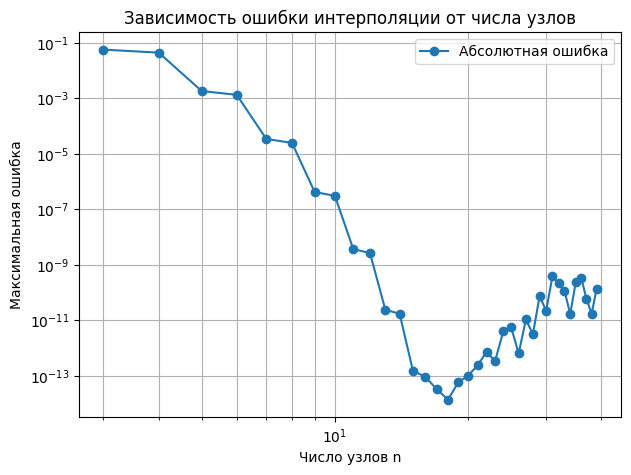

'При увеличении числа узлов интерполяция становится точнее — ошибка аппроксимации сначала уменьшается.\nОднако при слишком большом числе узлов возникают ошибки округления при вычислении коэффициентов многочлена.\nВ итоге ошибка начинает расти из-за накопления вычислительных ошибок и плохой обусловленности задачи интерполяции.\n'

In [ ]:
#Задание 1

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Функция для интерполяции и вычисления ошибки
def interpolation_error(f, a, b, n):
    # равномерные узлы
    x_nodes = np.linspace(a, b, n)
    y_nodes = f(x_nodes)
    
    # построение интерполяционного многочлена
    p = Polynomial.fit(x_nodes, y_nodes, n - 1)
    
    # проверяем ошибку на плотной сетке
    x_test = np.linspace(a, b, 1000)
    y_true = f(x_test)
    y_pred = p(x_test)
    
    # возвращаем абсолютную ошибку (максимум)
    return np.max(np.abs(y_true - y_pred))

# Интервал и функция
f = np.sin
a, b = 0, np.pi

# Разные числа узлов
nodes = np.arange(3, 40)
errors = [interpolation_error(f, a, b, n) for n in nodes]

# График
plt.figure(figsize=(7, 5))
plt.loglog(nodes, errors, 'o-', label='Абсолютная ошибка')
plt.xlabel('Число узлов n')
plt.ylabel('Максимальная ошибка')
plt.title('Зависимость ошибки интерполяции от числа узлов')
plt.grid(True, which='both')
plt.legend()
plt.show()



# Ответ: 
Рассмотрим матрицу Гильберта  $A_{ij}=\frac{1}{(i+j-1)}$

Число обусловленности показывает, насколько чувствительно решение СЛАУ Ax=b к малым изменениям данных.
Для матрицы Гильберта оно растёт экспоненциально с размерностью — потому что столбцы становятся всё более линейно зависимыми.
Такая матрица считается плохо обусловленной, и даже небольшие ошибки округления в численных вычислениях сильно искажают результат.


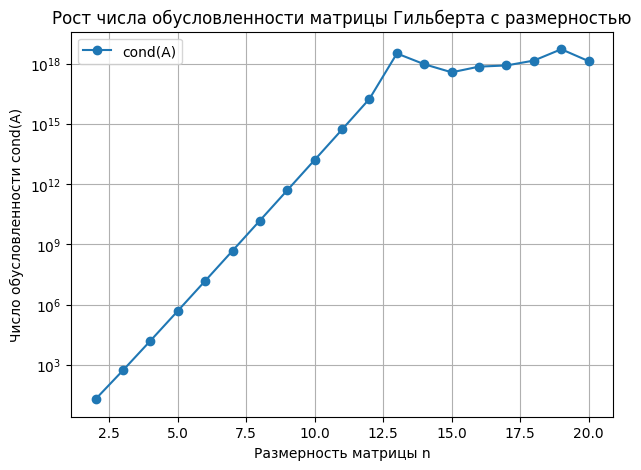

'\nЧисло обусловленности показывает, насколько чувствительно решение СЛАУ Ax=b к малым изменениям данных.\nДля матрицы Гильберта оно растёт экспоненциально с размерностью — потому что столбцы становятся всё более линейно зависимыми.\nТакая матрица считается плохо обусловленной, и даже небольшие ошибки округления в численных вычислениях сильно искажают результат.\n'

In [ ]:
#Задание 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hilbert
from numpy.linalg import cond
#from scipy.linalg import hilbert, cond

# Размерности
sizes = np.arange(2, 21)
conds = [cond(hilbert(n)) for n in sizes]

# График
plt.figure(figsize=(7, 5))
plt.semilogy(sizes, conds, 'o-', label='cond(A)')
plt.xlabel('Размерность матрицы n')
plt.ylabel('Число обусловленности cond(A)')
plt.title('Рост числа обусловленности матрицы Гильберта с размерностью')
plt.grid(True, which='both')
plt.legend()
plt.show()


## Часть 2. Оценка порядка точности метода (2 балла)

Рассмотрим метод с порядком точности $p$. Тогда ошибка метода $\epsilon_h = Ch^p$, где $h$ - сеточный шаг. На сетке с двое меньшим шагом ошибка метода будет $\epsilon_{h/2} = C_1 \left(\frac{h}{2}\right)^p$. Если шаг h достаточно мелкий (ф-я меняется не очень сильно), то можно считать, что $C \approx C_1$. Тогда, исключив $C$ из первого равенства за счет второго, можно получить, что
$$
p = \log_2 \frac{\epsilon_h}{\epsilon_{h/2}}
$$

Задание:

3. написать скрипт, который численно будет определять порядок точности методов направленная разность и центральная разность. Построить график зависимости p от шага сетки в широком диапазоне значений h. На графике для h использовать логарифмический масштаб. Объяснить поведение графиков. Исследуйте при это области как слева, так и справа от плато. Почему положения плато отличаются для двух методов и находятся именно на своих уровнях (обосновать аналитически).

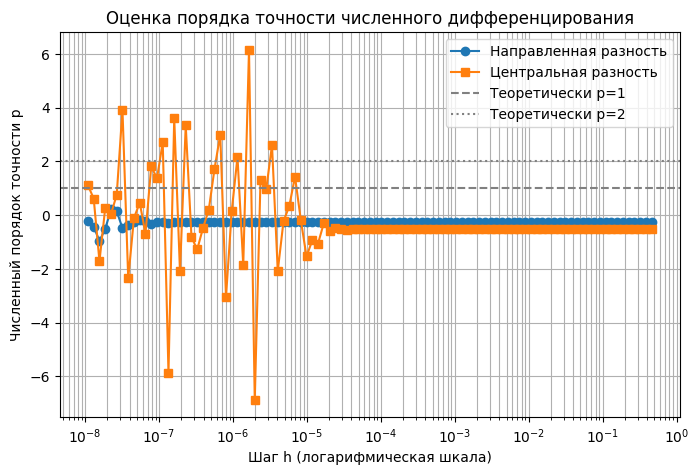

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Функция и её точная производная
f = np.sin
df = np.cos

x0 = 1.0  # точка, в которой считаем производную

# Массив шагов
h_values = np.logspace(-8, -0.3, 100)  # от 1e-8 до ~0.5

# Вычисляем ошибки
eps_forward = []
eps_central = []

for h in h_values:
    # направленная разность
    df_forward = (f(x0 + h) - f(x0)) / h
    # центральная разность
    df_central = (f(x0 + h) - f(x0 - h)) / (2 * h)
    
    # абсолютные ошибки
    eps_forward.append(abs(df_forward - df(x0)))
    eps_central.append(abs(df_central - df(x0)))

# Вычисляем численный порядок точности
def order(eps, h):
    return np.log2(eps[:-1] / eps[1:])

p_forward = order(np.array(eps_forward), h_values)
p_central = order(np.array(eps_central), h_values)
h_mid = np.sqrt(h_values[:-1] * h_values[1:])  # середина по логшкале

# График p(h)
plt.figure(figsize=(8,5))
plt.semilogx(h_mid, p_forward, 'o-', label='Направленная разность')
plt.semilogx(h_mid, p_central, 's-', label='Центральная разность')
plt.axhline(1, color='gray', ls='--', label='Теоретически p=1')
plt.axhline(2, color='gray', ls=':', label='Теоретически p=2')
plt.xlabel('Шаг h (логарифмическая шкала)')
plt.ylabel('Численный порядок точности p')
plt.title('Оценка порядка точности численного дифференцирования')
plt.grid(True, which='both')
plt.legend()
plt.show()



# Ответ:

При больших h:
Ошибка аппроксимации доминирует → оценка p может быть искажена.
Разность не отражает истинный порядок, т.к. члены высших порядков слишком велики.

При умеренных h:
Ошибка 
$\epsilon_h = Ch^p$ выполняется.
Появляется плато:
для направленной разности 𝑝≈1
для центральной разности p≈2

При очень малых h:
Ошибки округления начинают преобладать → относительная ошибка растёт.
Порядок p резко падает.

## Часть $3$. Дифференцирование с использованием полиномиальной интерполяции (2 балла)

Предложите вариант решения задачи численного дифференцирования на основании метода полиномиальной интерполяции по известным значениям функции. Реализуйте алгоритм, сравните его с МНК. Что общего у методов? 


# Ответ: 
Пусть функция f(x) известна в нескольких точках:
$$(x_0, f_0,(x_1, f_1),...,(x_n, f_n))$$

Тогда можно построить интерполяционный многочлен
$$P_n(x)=\sum_{k=0}^n f_k L_k(x)$$
$L_k(x)$ - полиномы Лагранжа

Производная функции в точке $x_0$ аппроксимируется производной полинома:
$$f'(x_0)\approx P_n'(x_0)$$

Это метод численного дифференцирования через полиномиальную интерполяцию.

Сравнение:
При полиномиальной интерполяции строится полином проходящий через все точки, не устойчива к ошибке погрешности, МНК - нет. 
Оба метода аппроксимируют функцию полиномом.
Дифференцирование в обоих случаях выполняется аналитически через производную полинома.

In [7]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt

f = np.sin
df = np.cos
x0 = 1.0

for n_points in [3, 5, 7]:
    h = 0.1
    x = np.linspace(x0 - h, x0 + h, n_points)
    y = f(x)

    # === Интерполяция ===
    poly = Polynomial.fit(x, y, n_points - 1)
    df_interp = poly.deriv()(x0)

    # === МНК ===
    coeffs = np.polyfit(x, y, deg=n_points - 1)
    p = np.poly1d(coeffs)
    df_lsq = np.polyder(p)(x0)

    print(f"n = {n_points}:")
    print(f"  Интерполяция: f'(x0) = {df_interp:.8f}, ошибка = {abs(df_interp - df(x0)):.2e}")
    print(f"  МНК:           f'(x0) = {df_lsq:.8f}, ошибка = {abs(df_lsq - df(x0)):.2e}")
    print()

n = 3:
  Интерполяция: f'(x0) = 0.53940225, ошибка = 9.00e-04
  МНК:           f'(x0) = 0.53940225, ошибка = 9.00e-04

n = 5:
  Интерполяция: f'(x0) = 0.54030219, ошибка = 1.13e-07
  МНК:           f'(x0) = 0.54030219, ошибка = 1.13e-07

n = 7:
  Интерполяция: f'(x0) = 0.54030231, ошибка = 5.29e-12
  МНК:           f'(x0) = 0.54030231, ошибка = 5.30e-12



## Часть 4. Пример проблемы использования метода Гаусса для решения СЛАУ (2 балл)

Перед вами простая реализация метода Гаусса для решения СЛАУ. Далее по коду представлены две СЛАУ $A_1x = b_1$ и $A_2x = b_2$, эквивалентные с точностью до перестановки строк. ЗАДАНИЕ: необходимо объяснить, почему для представленного метода Гаусса решения различаются.

In [8]:
import numpy as np
import copy 

def gauss( A_in, b_in ):
    n = b_in.size
    A = copy.deepcopy(A_in)
    b = copy.deepcopy(b_in)
    for k in range(0,n-1):
        for i in range(k+1,n):
            if A[i,k]!=0:
                c = A[i,k]/A[k,k]
                A[i,k+1:n] = A[i,k+1:n] - c*A[k,k+1:n]
                b[i] = b[i] - c*b[k]
                
    # обратный ход
    for k in range(n-1,-1,-1):
        b[k] = (b[k] - np.dot(A[k,k+1:n],b[k+1:n]))/A[k,k]
    return b

In [9]:
A1 = np.array([[1e-16, 1., -1.], 
               [-1., 2., -1.], 
               [2., -1., 0.]])

b1 = np.array([0., 0., 1.])

A2 = np.array([[2., -1., 0.], 
               [-1., 2., -1.], 
               [1e-16, 1., -1.]])

b2 = np.array([1., 0., 0.])

print('u1 = ', gauss(A1, b1))
print('u2 = ', gauss(A2, b2))

u1 =  [0.55511151 0.25       0.25      ]
u2 =  [1. 1. 1.]


Модифицировать метод Гаусса так, чтобы система $A_1x = b_1$ решалась корректно. ВАЖНО: реализация метода должна быть получена путем модификации метода gauss, а не переписыванием кода с нуля! 



# Ответ: 
Почему отличаются:
В A1 первый элемент $A_{11}=10^{-16}$ очень мал. В строке прямого хода формируется множитель
$$c=\frac{A[i,k]}{A[k,k]}$$

и далее вычитается c * A[k,k+1:n].
Из-за маленького $A_{11}$ возникают огромные ошибки округления, и результат сильно искажается.
В A2 ведущий элемент на первом шаге $A_{11}=2$ - ошибок нет
Именно поэтому, хотя системы эквивалентны с точностью до перестановки строк, решения u1 и u2 различаются.

Решение:
В методе Гаусса нужно на каждом шаге выбирать строку с максимальным по модулю элементом в текущем столбце и переставлять строки.

In [10]:
import numpy as np
import copy 

def gauss_pivot(A_in, b_in):
    n = b_in.size
    A = copy.deepcopy(A_in)
    b = copy.deepcopy(b_in)
    
    for k in range(0, n-1):
        # --- выбор ведущего элемента ---
        max_row = np.argmax(np.abs(A[k:n, k])) + k
        if max_row != k:
            A[[k, max_row], :] = A[[max_row, k], :]
            b[[k, max_row]] = b[[max_row, k]]
        
        for i in range(k+1, n):
            if A[i,k] != 0:
                c = A[i,k]/A[k,k]
                A[i,k+1:n] = A[i,k+1:n] - c*A[k,k+1:n]
                b[i] = b[i] - c*b[k]
                
    # обратный ход
    for k in range(n-1, -1, -1):
        b[k] = (b[k] - np.dot(A[k,k+1:n], b[k+1:n])) / A[k,k]
        
    return b


#Проверка:

u1 = gauss_pivot(A1, b1)
u2 = gauss_pivot(A2, b2)

print("u1 =", u1)
print("u2 =", u2)


u1 = [1. 1. 1.]
u2 = [1. 1. 1.]


## Часть 5. LU разложение (1 балл)

Задание: 

реализовать алгоритм решения предыдущей задачи с матрицей A2 с помощью LU-разложение В решении должна выводиться L, U и собственно решение системы. 

ВАЖНО: реализация метода LU должна быть получена путем небольшой модификации метода gauss!  При это саму реализацию можно разделить на два метода: один метод собственно находит LU разложение (можно сделать переделкой цикла для матрицы A метода gauss), второй метод - непосредственное решение системы с помощью прямого и обратного хода. Ни в каком виде нельзя пользоваться пакетными методами (в частности, la.solve)

In [11]:
import numpy as np
import copy

def lu_decomposition(A_in):
    n = A_in.shape[0]
    A = copy.deepcopy(A_in)
    L = np.eye(n)
    U = copy.deepcopy(A_in)
    
    for k in range(n-1):
        for i in range(k+1, n):
            if U[i,k] != 0:
                c = U[i,k] / U[k,k]
                L[i,k] = c
                U[i,k:] = U[i,k:] - c * U[k,k:]
    
    return L, U
def lu_solve(L, U, b):
    n = b.size
    y = np.zeros_like(b)
    
    # прямой ход: L y = b
    for i in range(n):
        y[i] = b[i] - np.dot(L[i,:i], y[:i])
    
    # обратный ход: U x = y
    x = np.zeros_like(b)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - np.dot(U[i,i+1:], x[i+1:])) / U[i,i]
    
    return x

A2 = np.array([[2., -1., 0.], 
               [-1., 2., -1.], 
               [1e-16, 1., -1.]])
b2 = np.array([1., 0., 0.])

L, U = lu_decomposition(A2)
x = lu_solve(L, U, b2)

print("L =\n", L)
print("U =\n", U)
print("Решение x =", x)



L =
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-5.00000000e-01  1.00000000e+00  0.00000000e+00]
 [ 5.00000000e-17  6.66666667e-01  1.00000000e+00]]
U =
 [[ 2.         -1.          0.        ]
 [ 0.          1.5        -1.        ]
 [ 0.          0.         -0.33333333]]
Решение x = [1. 1. 1.]


## Часть 6. Нахождение обратной матрицы с помощью LU разложения (1 балл)

Задание:

Предложить алгоритм с использованием LU-разложения и найти обратную матрицу с точностью $\epsilon = 10^{-3}$:
$$
A = \begin{pmatrix} 
1 & 1  & 1 \\
0 & 1 & 2 \\
7 & 1 & 4 \\
\end{pmatrix}
$$
Для необходимых оценок использовать первую норму. Сравнить результат со значением, найденным с помощью функции numpy.linalg.inv.

In [ ]:
import numpy as np
import copy

def lu_decomposition(A_in):
    """LU-разложение (без перестановок): A = L * U"""
    A = copy.deepcopy(A_in).astype(float)
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    for k in range(n):
        # элементы верхней треугольной матрицы
        for j in range(k, n):
            U[k, j] = A[k, j] - np.dot(L[k, :k], U[:k, j])
        # элементы нижней треугольной матрицы
        for i in range(k + 1, n):
            if abs(U[k, k]) < 1e-15:
                raise ZeroDivisionError("Нулевой ведущий элемент — нужен pivoting.")
            L[i, k] = (A[i, k] - np.dot(L[i, :k], U[:k, k])) / U[k, k]
    return L, U


def lu_solve(L, U, b):
    """Решает систему A x = b, где A = L * U"""
    n = b.size
    # прямой ход (L y = b)
    y = np.zeros_like(b, dtype=float)
    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])
    # обратный ход (U x = y)
    x = np.zeros_like(b, dtype=float)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]
    return x


def inverse_via_lu(A, eps=1e-3):
    """Находит обратную матрицу A^{-1} с помощью LU-разложения"""
    n = A.shape[0]
    L, U = lu_decomposition(A)
    inv_A = np.zeros_like(A, dtype=float)
    for j in range(n):
        e = np.zeros(n)
        e[j] = 1.0
        inv_A[:, j] = lu_solve(L, U, e)

    # Проверка точности
    I = np.eye(n)
    residual = I - A @ inv_A
    err_norm = np.linalg.norm(residual, 1)

    return L, U, inv_A, err_norm


# ======= ТЕСТ =======
A = np.array([
    [1., 1., 1.],
    [0., 1., 2.],
    [7., 1., 4.]
])

L, U, A_inv, err = inverse_via_lu(A)

print("L =\n", L)
print("\nU =\n", U)
print("\nA⁻¹ (через LU) =\n", A_inv)
print("\nA⁻¹ (numpy) =\n", np.linalg.inv(A))
print(f"\n||I - A*A⁻¹||₁ = {err:.3e}")


L =
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 7. -6.  1.]]

U =
 [[1. 1. 1.]
 [0. 1. 2.]
 [0. 0. 9.]]

A⁻¹ (через LU) =
 [[ 0.22222222 -0.33333333  0.11111111]
 [ 1.55555556 -0.33333333 -0.22222222]
 [-0.77777778  0.66666667  0.11111111]]

A⁻¹ (numpy) =
 [[ 0.22222222 -0.33333333  0.11111111]
 [ 1.55555556 -0.33333333 -0.22222222]
 [-0.77777778  0.66666667  0.11111111]]

||I - A*A⁻¹||₁ = 5.551e-16
